In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("spam.csv")

# Check column names (optional, in case of formatting issues)
print(df.columns)

# Ensure correct column names (adjust if needed)
# df = df.rename(columns={"v1": "Category", "v2": "Message"})

# Separate classes
spam_df = df[df["Category"] == "spam"]
ham_df = df[df["Category"] == "ham"]

# Randomly sample 50 from each class
spam_sample = spam_df.sample(n=50, random_state=42)
ham_sample = ham_df.sample(n=50, random_state=42)

# Combine and shuffle
sample_df = pd.concat([spam_sample, ham_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

# Save to new CSV
sample_df.to_csv("sample_dataset.csv", index=False)

print("Sample dataset created: sample_dataset.csv")

Index(['Category', 'Message'], dtype='object')
Sample dataset created: sample_100.csv


In [2]:
# Regular expressions library for text cleaning (e.g., removing special characters, numbers)
import re

# Pandas for loading and manipulating datasets (DataFrame structure)
import pandas as pd

# Stopwords list (common words like "the", "is") from NLTK for text preprocessing
from nltk.corpus import stopwords

# TF-IDF Vectorizer converts text into numerical feature vectors based on term frequency
from sklearn.feature_extraction.text import TfidfVectorizer

# Splits the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Multinomial Naive Bayes algorithm — commonly used for text classification
from sklearn.naive_bayes import MultinomialNB

# Functions to evaluate model performance (accuracy, classification report, confusion matrix)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Natural Language Toolkit — used here mainly to download resources (like stopwords)
import nltk

# Joblib for saving and loading trained models or transformers efficiently
import joblib

# Seaborn for visually appealing statistical plots (like heatmaps of confusion matrix)
import seaborn as sns

# Matplotlib for creating and customizing visualizations
import matplotlib.pyplot as plt

# Additional metrics to evaluate the model’s precision, recall, and F1-score
from sklearn.metrics import precision_score, recall_score, f1_score

In [3]:
import pandas as pd

# Load the dataset (email spam dataset with 'category' and 'message' columns)
data = pd.read_csv("sample_dataset.csv")

# Print a header for clarity
print("\n\nEmail Spam Dataset:")
print("============\n")

# Configure pandas to display ALL rows and columns
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Print total number of samples
print(f'Total number of samples in dataset = {len(data)}\n')

# Display ALL rows
print(data)



Email Spam Dataset:

Total number of samples in dataset = 100

   Category                                            Message
0       ham                           LOL ... No just was busy
1       ham  I thk 50 shd be ok he said plus minus 10.. Did...
2       ham  Hey you can pay. With salary de. Only  &lt;#&g...
3      spam  UpgrdCentre Orange customer, you may now claim...
4      spam  Bloomberg -Message center +447797706009 Why wa...
5      spam  Not heard from U4 a while. Call 4 rude chat pr...
6      spam  Urgent! Please call 09066612661 from your land...
7       ham  Lol ... I really need to remember to eat when ...
8      spam  You have WON a guaranteed £1000 cash or a £200...
9      spam  Summers finally here! Fancy a chat or flirt wi...
10     spam  I don't know u and u don't know me. Send CHAT ...
11     spam  Your B4U voucher w/c 27/03 is MARSMS. Log onto...
12      ham  There the size of elephant tablets & u shove u...
13     spam  Hi 07734396839 IBH Customer Loyalty Offe

In [4]:
# Display all column names of the dataset
# This helps to understand what features are available in 'data'
data.columns

Index(['Category', 'Message'], dtype='object')

In [7]:

# Create a balanced sample dataset with 100 instances (50 spam, 50 ham)

# Filter the data to include only 'spam' and 'ham' categories
filtered_data = data[data['Category'].isin(['spam', 'ham'])]

# Group the filtered data by 'category' and take 50 samples from each group.
# If a category has less than 50 instances, take all available instances.
sample_data = filtered_data.groupby('Category').apply(
    lambda x: x.sample(n=min(len(x), 50), random_state=42)
)

# Reset the index of the resulting DataFrame, dropping the old index
sample_data = sample_data.reset_index(drop=True)

# Print the total number of samples in the balanced dataset
print(f'Balanced sample data count = {len(sample_data)}\n')

# Display the balanced sample dataset
display(sample_data)

Balanced sample data count = 100



/tmp/ipykernel_1110/1227546502.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_data = filtered_data.groupby('Category').apply(


,Category,Message
0,ham,Do you know why god created gap between your f...
1,ham,Hahaha..use your brain dear
2,ham,I agree. So i can stop thinkin about ipad. Can...
3,ham,"Hey chief, can you give me a bell when you get..."
4,ham,I.ll get there tomorrow and send it to you
5,ham,Do u hav any frnd by name ashwini in ur college?
6,ham,If i not meeting ü all rite then i'll go home ...
7,ham,Dunno i juz askin cos i got a card got 20% off...
8,ham,I HAVE A DATE ON SUNDAY WITH WILL!!
9,ham,Or I guess &lt;#&gt; min


In [8]:
# Count the number of unique categories in the balanced sample dataset
num_labels = sample_data['Category'].nunique()
print(f"Number of unique categories: {num_labels}")

# Count the number of instances for each category
label_counts = sample_data['Category'].value_counts()
print("\nNumber of instances for each category:")
print(label_counts)

Number of unique categories: 2

Number of instances for each category:
Category
ham     50
spam    50
Name: count, dtype: int64


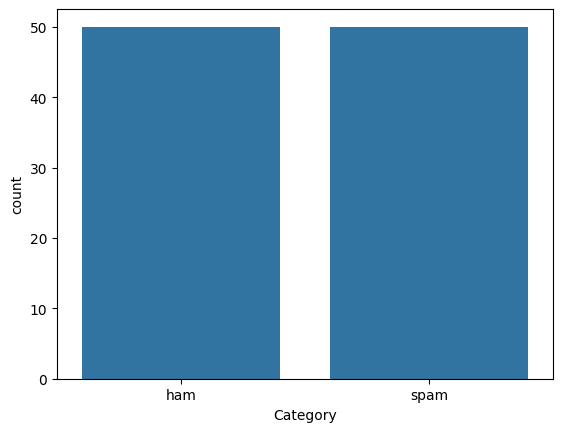

In [9]:
sns.countplot( x = 'Category', data = sample_data );

In [10]:
# save sample_data as .csv file
sample_data.to_csv("sample_comments.csv", index=False)

In [11]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [12]:
# Download NLTK resources
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [13]:
# Load dataset
data = pd.read_csv("sample_comments.csv")

In [14]:
# Step 1: Drop rows with missing messages
data = data.dropna(subset=['Message'])

# Step 2: Initialize stopwords and stemmer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

# Step 3: Define text cleaning function
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove phone numbers
    text = re.sub(r'\b\d{5,}\b', '', text)
    # Remove special characters, punctuation, numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords and apply stemming
    text = ' '.join([stemmer.stem(word) for word in text.split() if word not in stop_words])
    return text

# Step 4: Apply cleaning function
data['clean_message'] = data['Message'].apply(clean_text)



In [15]:
# Step 5: Preview cleaned data
print("Data after cleaning:")
print(data.head())

# Step 6: Save cleaned data to new CSV
data.to_csv("clean_sample_data.csv", index=False)
print("\nCleaned data saved to 'clean_sample_data.csv'")

Data after cleaning:
  Category                                            Message  \
0      ham  Do you know why god created gap between your f...   
1      ham                        Hahaha..use your brain dear   
2      ham  I agree. So i can stop thinkin about ipad. Can...   
3      ham  Hey chief, can you give me a bell when you get...   
4      ham         I.ll get there tomorrow and send it to you   

                                       clean_message  
0  know god creat gap finger one made come amp fi...  
1                                hahahaus brain dear  
2    agre stop thinkin ipad pleas ask macho question  
3  hey chief give bell get need talk royal visit ...  
4                              ill get tomorrow send  

Cleaned data saved to 'clean_sample_data.csv'


In [16]:
# Display the column names of the DataFrame.
# This helps confirm that the DataFrame has the expected structure
# (for example after reordering or saving to a CSV).
data.columns

Index(['Category', 'Message', 'clean_message'], dtype='object')

In [18]:

# Load cleaned email dataset (after preprocessing)
data = pd.read_csv("clean_sample_data.csv")

# Encode labels: ham=0, spam=1
data['label'] = data['Category'].map({'ham': 0, 'spam': 1})

# Separate features (X) and labels (y)
X = data['clean_message']  # use cleaned text
y = data['label']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print how many samples ended up in training and test sets
print(f"Number of training samples: {len(X_train)}")
print(f"Number of testing samples: {len(X_test)}")

# Display the first few training samples
print("\nSample training data:")
print(X_train.head())

# Initialize the TF-IDF Vectorizer to convert text into numerical feature vectors
# You can adjust max_features depending on your dataset size and ML model
vectorizer = TfidfVectorizer(max_features=1000)  # increased from 10 for better representation

# Fit the vectorizer on training data and transform
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF feature shape (train):", X_train_tfidf.shape)
print("TF-IDF feature shape (test):", X_test_tfidf.shape)

Number of training samples: 80
Number of testing samples: 20

Sample training data:
15                          mathew tait edward anderson
52    privat account statement show unredeem point c...
60    enjoy jamster videosound gold club credit new ...
66              free entri weekli comp send word win tc
68    great news call freefon claim guarante cash gi...
Name: clean_message, dtype: object

TF-IDF feature shape (train): (80, 543)
TF-IDF feature shape (test): (20, 543)


In [19]:
# Convert email text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=1000)  # better for emails

In [20]:
vectorizer.fit(X_train)

TfidfVectorizer(max_features=1000)

In [21]:
# Transform training and test sets into TF-IDF feature matrices
X_train_tfidf = vectorizer.transform(X_train)

print("Training feature matrix shape:", X_train_tfidf.shape)

Training feature matrix shape: (80, 543)


In [22]:
# Convert the TF-IDF sparse matrix for the training data into a dense (regular) array,
# then wrap it into a pandas DataFrame for easier viewing and manipulation.
# 'columns=vectorizer.get_feature_names_out()' names the columns after the TF-IDF terms.
X_train_tfidf_df = pd.DataFrame(
    X_train_tfidf.toarray(),                 # convert sparse matrix to dense array
    columns=vectorizer.get_feature_names_out()  # use the learned vocabulary as column names
)

# Round all TF-IDF values to 2 decimal places for cleaner display.
X_train_tfidf_df = X_train_tfidf_df.round(2)

# Print a header for clarity and then show the first 5 rows of the DataFrame.
print("\nTF-IDF Features DataFrame (2 decimal places):")

X_train_tfidf_df.head()


TF-IDF Features DataFrame (2 decimal places):


,abroad,ac,accid,account,actin,action,actual,ad,adam,addamsfa,address,age,agre,aight,also,alway,amp,anderson,anymor,apologet,appli,area,ashwini,ask,ass,await,away,baaaaab,babe,back,badli,bannfwflyppm,barkley,bath,bb,bell,big,bit,blond,bloomberg,bloombergcom,bluetooth,bodi,booti,bowl,box,boytoy,brain,bray,brilliant,bring,bslvyl,btnationalr,bu,busi,buy,bx,bxipw,call,calloptoutyhl,cancer,car,care,cash,cashbal,cashin,caught,cc,center,chanc,channel,charg,chart,chat,cheer,chief,child,cinema,claim,class,club,co,code,collect,colleg,come,comin,comp,complimentari,comput,condit,congrat,congratul,contact,content,continu,correct,cost,costa,coupl,cr,crazi,creat,credit,croydon,cs,cum,current,custcar,custom,dad,damn,date,day,de,dear,def,del,detroit,devil,didnt,discount,divert,dload,dobbi,doesnt,dont,doubl,download,dracula,drink,drinkpa,dun,easi,edward,eeri,eg,ehrr,eir,eleph,end,enjoy,enter,entri,envelop,etc,europ,eve,even,everi,exorcist,expir,fallen,fan,fanci,fantasi,fb,feel,feelingood,fill,final,find,fine,finger,finish,flight,flirt,forward,free,freefon,friend,frnd,fun,futur,game,gap,gbpweek,get,gettin,ghost,gift,give,given,gnarl,go,god,goe,gold,gonna,good,goodfin,got,gr,grasp,great,guarante,guess,guy,hahahaus,hand,hav,havbeen,havebeen,heard,heart,hello,help,hero,hey,hgsuitelandsrowwjhl,hi,hit,hockey,hol,hold,holiday,home,hope,horni,hot,hr,html,ice,id,identifi,ill,im,incorrect,increment,ip,ipad,jame,jamster,jamstercouk,java,jersey,job,join,jordan,june,kate,ki,kiss,know,kwish,landlin,last,latebut,latest,ldn,leav,lectur,let,like,line,live,log,logo,logosmusicnew,lol,lone,long,look,lor,lot,love,lover,lovli,ltd,ltgt,luv,lux,macho,made,mail,make,marsm,match,mate,mathew,matrix,matur,maxim,med,meet,member,messag,mfl,might,mila,min,minu,minut,miss,misss,mix,mk,mobil,mobileupd,mobno,model,motorola,movi,msg,mtalk,munster,music,must,muz,mytonecomenjoy,nake,name,nation,nd,need,new,news,next,nice,nicenicehow,night,nokia,nolin,norm,ntt,nz,offer,oh,ok,omw,one,onto,oper,opt,optout,orang,pa,paragraph,pass,pay,payedday,pdatenow,per,pg,phone,pic,pick,pix,pl,play,player,pleas,plu,pm,pmsg,po,pobox,poboxwwq,point,polyh,polytruepixringtonesgam,pound,ppm,pptxt,preschoolcoordin,pretti,privat,prize,prizeto,progress,prospect,question,quiz,rate,rcvd,real,realli,receiv,reciev,red,rememb,rentl,repli,repres,right,rington,rip,rise,rite,royal,rpli,rude,sae,said,salari,sam,satjust,saturday,savamob,say,see,self,send,sept,servic,sex,sexi,shag,shd,shop,shove,show,side,sign,sim,singl,six,size,slaaaaav,sm,small,sol,someth,sonyericsson,soon,sorri,speak,special,spirit,spoilt,sport,sptv,sr,st,stamp,start,starwar,statement,stop,stopcost,str,sub,summer,summon,sunday,sunshin,suprman,sure,tablet,tait,take,talk,tariff,tc,tcrw,teach,teas,teletext,term,text,th,thank,thing,think,thinkin,thk,til,till,time,tip,titl,today,told,tomorrow,tone,took,top,total,tri,tsc,twelv,twilight,two,txt,txtno,txtp,uk,um,understand,unredeem,unsold,unsub,unsubscrib,ur,urgent,us,usual,valu,via,videochat,videophon,videosound,visionsmscom,visit,vodafon,voucher,wadebridgei,wait,wan,wanna,want,wap,wb,wc,week,weekend,weekli,well,wi,wicklow,wid,win,wing,wish,within,wk,wont,word,work,worth,write,wt,xma,xpwk,xxsp,xxx,yahoo,ye,yeah,year,yeh,youuuuu,yr
0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0

In [23]:
# Transform test emails into TF-IDF features
X_test_tfidf = vectorizer.transform(X_test)

# Convert to DataFrame (only for inspection; keep sparse for modeling large datasets)
X_test_tfidf_df = pd.DataFrame(
    X_test_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)

# Optional: include labels for inspection
X_test_tfidf_df['label'] = y_test.reset_index(drop=True)

print("\nTF-IDF Features DataFrame (Test Set):")
X_test_tfidf_df.head()


TF-IDF Features DataFrame (Test Set):


,abroad,ac,accid,account,actin,action,actual,ad,adam,addamsfa,address,age,agre,aight,also,alway,amp,anderson,anymor,apologet,appli,area,ashwini,ask,ass,await,away,baaaaab,babe,back,badli,bannfwflyppm,barkley,bath,bb,bell,big,bit,blond,bloomberg,bloombergcom,bluetooth,bodi,booti,bowl,box,boytoy,brain,bray,brilliant,bring,bslvyl,btnationalr,bu,busi,buy,bx,bxipw,call,calloptoutyhl,cancer,car,care,cash,cashbal,cashin,caught,cc,center,chanc,channel,charg,chart,chat,cheer,chief,child,cinema,claim,class,club,co,code,collect,colleg,come,comin,comp,complimentari,comput,condit,congrat,congratul,contact,content,continu,correct,cost,costa,coupl,cr,crazi,creat,credit,croydon,cs,cum,current,custcar,custom,dad,damn,date,day,de,dear,def,del,detroit,devil,didnt,discount,divert,dload,dobbi,doesnt,dont,doubl,download,dracula,drink,drinkpa,dun,easi,edward,eeri,eg,ehrr,eir,eleph,end,enjoy,enter,entri,envelop,etc,europ,eve,even,everi,exorcist,expir,fallen,fan,fanci,fantasi,fb,feel,feelingood,fill,final,find,fine,finger,finish,flight,flirt,forward,free,freefon,friend,frnd,fun,futur,game,gap,gbpweek,get,gettin,ghost,gift,give,given,gnarl,go,god,goe,gold,gonna,good,goodfin,got,gr,grasp,great,guarante,guess,guy,hahahaus,hand,hav,havbeen,havebeen,heard,heart,hello,help,hero,hey,hgsuitelandsrowwjhl,hi,hit,hockey,hol,hold,holiday,home,hope,horni,hot,hr,html,ice,id,identifi,ill,im,incorrect,increment,ip,ipad,jame,jamster,jamstercouk,java,jersey,job,join,jordan,june,kate,ki,kiss,know,kwish,landlin,last,latebut,latest,ldn,leav,lectur,let,like,line,live,log,logo,logosmusicnew,lol,lone,long,look,lor,lot,love,lover,lovli,ltd,ltgt,luv,lux,macho,made,mail,make,marsm,match,mate,mathew,matrix,matur,maxim,med,meet,member,messag,mfl,might,mila,min,minu,minut,miss,misss,mix,mk,mobil,mobileupd,mobno,model,motorola,movi,msg,mtalk,munster,music,must,muz,mytonecomenjoy,nake,name,nation,nd,need,new,news,next,nice,nicenicehow,night,nokia,nolin,norm,ntt,nz,offer,oh,ok,omw,one,onto,oper,opt,optout,orang,pa,paragraph,pass,pay,payedday,pdatenow,per,pg,phone,pic,pick,pix,pl,play,player,pleas,plu,pm,pmsg,po,pobox,poboxwwq,point,polyh,polytruepixringtonesgam,pound,ppm,pptxt,preschoolcoordin,pretti,privat,prize,prizeto,progress,prospect,question,quiz,rate,rcvd,real,realli,receiv,reciev,red,rememb,rentl,repli,repres,right,rington,rip,rise,rite,royal,rpli,rude,sae,said,salari,sam,satjust,saturday,savamob,say,see,self,send,sept,servic,sex,sexi,shag,shd,shop,shove,show,side,sign,sim,singl,six,size,slaaaaav,sm,small,sol,someth,sonyericsson,soon,sorri,speak,special,spirit,spoilt,sport,sptv,sr,st,stamp,start,starwar,statement,stop,stopcost,str,sub,summer,summon,sunday,sunshin,suprman,sure,tablet,tait,take,talk,tariff,tc,tcrw,teach,teas,teletext,term,text,th,thank,thing,think,thinkin,thk,til,till,time,tip,titl,today,told,tomorrow,tone,took,top,total,tri,tsc,twelv,twilight,two,txt,txtno,txtp,uk,um,understand,unredeem,unsold,unsub,unsubscrib,ur,urgent,us,usual,valu,via,videochat,videophon,videosound,visionsmscom,visit,vodafon,voucher,wadebridgei,wait,wan,wanna,want,wap,wb,wc,week,weekend,weekli,well,wi,wicklow,wid,win,wing,wish,within,wk,wont,word,work,worth,write,wt,xma,xpwk,xxsp,xxx,yahoo,ye,yeah,year,yeh,youuuuu,yr,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.372627,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0

In [24]:
# Check the type of X_train_tfidf
print(type(X_train_tfidf))  # Should be <class 'scipy.sparse.csr.csr_matrix'>

# Check the shape: (number of samples, number of features)
print("Shape of X_train_tfidf:", X_train_tfidf.shape)

# Optionally, view the first 5 rows as a dense array (small datasets only)
print(X_train_tfidf.toarray()[:5])

<class 'scipy.sparse._csr.csr_matrix'>
Shape of X_train_tfidf: (80, 543)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [25]:
# Check first 10 values
print(y_train.head(10))

# Check unique values
print("Unique labels in y_train:", y_train.unique())

# Optional: check type
print("Type of y_train:", type(y_train))

15    0
52    1
60    1
66    1
68    1
6     0
31    0
59    1
46    0
99    1
Name: label, dtype: int64
Unique labels in y_train: [0 1]
Type of y_train: <class 'pandas.core.series.Series'>


In [26]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [27]:
joblib.dump(model, 'naive_bayes_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']

In [28]:
# Load saved model and vectorizer
model = joblib.load('naive_bayes_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

# Transform new emails and predict
new_emails = ["Congratulations! You won a $1000 prize!", "Hey, are we meeting today?"]
new_emails_clean = [clean_text(email) for email in new_emails]
new_emails_tfidf = vectorizer.transform(new_emails_clean)
predictions = model.predict(new_emails_tfidf)

print(predictions)  # 1=spam, 0=ham

[1 0]



Evaluation Metrics:


,Accuracy,Precision,Recall,F1-Score
0,1.0,1.0,1.0,1.0



Confusion Matrix Table:


,Predicted Ham,Predicted Spam
Actual Ham,10,0
Actual Spam,0,10


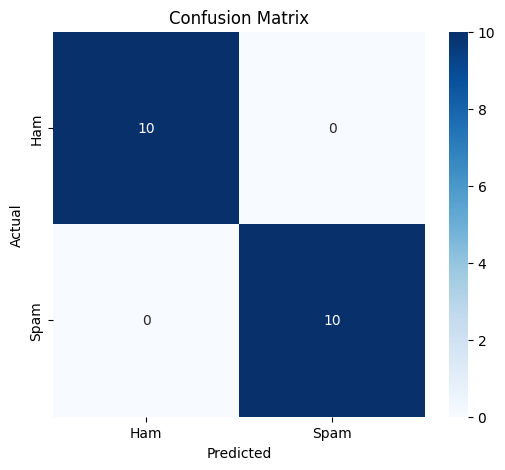

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

# --- Load saved model and vectorizer (you already did this) ---
model = joblib.load('naive_bayes_model.pkl')
vectorizer = joblib.load('tfidf_vectorizer.pkl')

# --- Prepare test data ---
# Make sure X_test contains the cleaned messages (clean_message column)
X_test_clean = X_test.apply(clean_text)  # only if not cleaned yet

# Transform test data using loaded vectorizer
X_test_tfidf_loaded = vectorizer.transform(X_test_clean)

# Predict labels on test data
y_pred_loaded = model.predict(X_test_tfidf_loaded)

# --- Compute Evaluation Metrics ---
accuracy  = accuracy_score(y_test, y_pred_loaded)
precision = precision_score(y_test, y_pred_loaded, average='weighted')
recall    = recall_score(y_test, y_pred_loaded, average='weighted')
f1        = f1_score(y_test, y_pred_loaded, average='weighted')

metrics_df = pd.DataFrame({
    'Accuracy':  [accuracy],
    'Precision': [precision],
    'Recall':    [recall],
    'F1-Score':  [f1]
})

print("\nEvaluation Metrics:")
display(metrics_df)

# --- Confusion Matrix Table ---
conf_matrix = confusion_matrix(y_test, y_pred_loaded)
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=['Actual Ham', 'Actual Spam'],
    columns=['Predicted Ham', 'Predicted Spam']
)

print("\nConfusion Matrix Table:")
display(conf_matrix_df)

# --- Plot Confusion Matrix Heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(
    conf_matrix,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [33]:
# Compute accuracy as a decimal
accuracy = accuracy_score(y_test, y_pred_loaded)

# Convert to percentage
accuracy_percent = accuracy * 100

print(f"Accuracy: {accuracy_percent:.2f}%")

Accuracy: 100.00%
